In [7]:
# CODE FOR CELL 1
from curl_cffi import requests as requests_cffi
import time
import pandas as pd

# Gunakan kata kunci barang murah agar panen Bintang 1-3 berjalan kilat
daftar_keyword = [
    # --- KECANTIKAN & PERAWATAN DIRI ---
    # "serum wajah", "sunscreen", "pelembap wajah", "sabun cuci muka", 
    # "toner wajah", "micellar water", "masker wajah", "body lotion", 
    # "lipstik matte", "lip tint", "bedak tabur", "foundation wajah",
    # "parfum wanita", "parfum pria", "deodorant", "sampo anti ketombe", 
    # "lulur mandi", "kapas kecantikan",

    # # --- ELEKTRONIK & GADGET MURAH (Medan Perang Ulasan) ---
    # "headset murah", "earphone murah", "kabel data murah", "charger murah",
    # "powerbank murah", "jam tangan murah", "kipas angin mini", "tripod hp",
    # "mouse wireless", "keyboard mekanik", "flashdisk 64gb", "micro sd murah" "stop kontak",

    # # --- MAKANAN & MINUMAN ---
    # "kopi bubuk", "kopi instan", "teh celup", "susu UHT", 
    # "mie instan goreng", "mie instan kuah", "bumbu nasi goreng", 
    # "kecap manis", "saus sambal", "minyak goreng", "camilan gurih", "sosis sapi", "nugget ayam",

    # # --- PAKAIAN, FASHION & AKSESORIS MURAH ---
    # "kaos polos murah", "dompet murah", "baju kemeja murah", "sandal slop murah", 
    # "sepatu murah", "kaos kaki katun", "celana jeans pria", "celana kulot wanita", 
    # "jaket hoodie", "tas ransel pria", "tas selempang wanita", "kacamata hitam",

    # # --- KEBUTUHAN RUMAH TANGGA & ATK ---
    # "deterjen cair", "pewangi pakaian", "sabun cuci piring", "handuk mandi", 
    # "sprei kasur", "botol minum tumbler", "kotak makan plastik", "rak sepatu", 
    # "buku tulis", "pulpen hitam", "pensil mekanik", "spidol papan tulis", "sticky notes",
    # "rak jepit", "barang unik", 
    "payung lipat"
]

# Target 20.000 / 4 kelas = 5.000 ulasan per bintang
# TARGET_GLOBAL_PER_RATING = 5000 
TARGET_GLOBAL_PER_RATING = 10000
TARGET_RATINGS = [1, 2, 3, 5]

kuota_global = {1: 0, 2: 0, 3: 0, 5: 0}
semua_id_produk = []
hasil_ulasan = []

url_gql = "https://gql.tokopedia.com/graphql"

headers_tokped = {
    "Content-Type": "application/json",
    "x-device": "desktop",
    "Origin": "https://www.tokopedia.com",
    "Referer": "https://www.tokopedia.com/",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "x-source": "tokopedia-lite" # Kadang ini kunci pembuka akses
}
print(f"Sistem Siap! Menargetkan total 20k data Tokopedia (~{TARGET_GLOBAL_PER_RATING} per kelas bintang).")

Sistem Siap! Menargetkan total 20k data Tokopedia (~10000 per kelas bintang).


In [2]:
# CODE FOR CELL 2 (PERBAIKAN URL RESMI)
import time
import pandas as pd
from curl_cffi import requests as requests_cffi

print("=== MEMULAI TAHAP 1: PENCARIAN PRODUCT ID TOKOPEDIA (V5) ===")

mentah_produk = []

# PERBAIKAN: Menggunakan URL resmi gql.tokopedia.com tanpa static
url_gql_v5 = "https://gql.tokopedia.com/graphql/SearchProductV5Query"

for keyword in daftar_keyword:
    print(f"Mencari produk terlaris untuk: '{keyword}'...")
    
    payload_search = {
        "operationName": "SearchProductV5Query",
        "variables": {
            "params": f"device=desktop&navsource=home&ob=5&q={keyword}&rows=50&source=search&start=0"
        },
        "query": """query SearchProductV5Query($params: String!) {
          searchProductV5(params: $params) {
            data {
              products {
                id
                name
                url
              }
            }
          }
        }""" 
    }
    
    headers_lengkap = {
        "Content-Type": "application/json",
        "x-device": "desktop",
        "Origin": "https://www.tokopedia.com",
        "Referer": "https://www.tokopedia.com/",
        "Accept": "*/*",
        "Accept-Language": "id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7"
    }
    
    try:
        res = requests_cffi.post(url_gql_v5, headers=headers_lengkap, json=payload_search, impersonate="chrome110")
        
        if res.status_code == 200:
            res_json = res.json()
            data_wrapper = res_json[0] if isinstance(res_json, list) else res_json
            
            # Parsing data berdasarkan peta JSON akurat yang kamu kirim kemarin
            search_v5 = data_wrapper.get('data', {}).get('searchProductV5', {})
            search_data = search_v5.get('data', {}) if search_v5 else {}
            products = search_data.get('products', []) if search_data else []
            
            jumlah_baru = 0
            if products:
                for p in products:
                    if isinstance(p, dict):
                        p_id = p.get('id')
                        p_url = p.get('url')
                        if p_id:
                            mentah_produk.append({
                                "keyword": keyword,
                                "product_id": str(p_id),
                                "url_produk": p_url
                            })
                            jumlah_baru += 1
                print(f"  -> Berhasil mencatat {jumlah_baru} produk unik.")
            else:
                print("  [!] Array 'products' kosong. Struktur payload atau header mungkin ditolak Tokopedia.")
                if 'errors' in data_wrapper:
                    print(f"  [DEBUG API ERROR]: {data_wrapper.get('errors')}")
        else:
            print(f"  [!] Gagal akses API Tokopedia (HTTP Status: {res.status_code})")
            
    except Exception as e:
        print(f"  [!] Gagal memproses data karena Exception: {e}")
        
    time.sleep(2)

# --- PROSES DROP DUPLICATE & SAVE CHECKPOINT CSV ---
if mentah_produk:
    df_produk = pd.DataFrame(mentah_produk)
    total_awal = len(df_produk)
    df_produk_clean = df_produk.drop_duplicates(subset=['product_id'])
    total_akhir = len(df_produk_clean)
    
    print("\n=== EKSTRAKSI TAHAP 1 SELESAI ===")
    print(f"Total ID Produk Terkumpul: {total_awal} | ID Produk Unik Tersimpan: {total_akhir}")
    
    df_produk_clean.to_csv("daftar_id_tokped.csv", index=False, encoding='utf-8')
    print("[V] Berhasil mengamankan berkas checkpoint: 'daftar_id_tokped.csv'")
else:
    print("\n[!] Tahap 1 Gagal: Sama sekali tidak ada data ID Produk yang masuk.")

=== MEMULAI TAHAP 1: PENCARIAN PRODUCT ID TOKOPEDIA (V5) ===
Mencari produk terlaris untuk: 'serum wajah'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'sunscreen'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'pelembap wajah'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'sabun cuci muka'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'toner wajah'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'micellar water'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'masker wajah'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'body lotion'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'lipstik matte'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'lip tint'...
  -> Berhasil mencatat 50 produk unik.
Mencari produk terlaris untuk: 'bedak tabur'...
  -> Berhasil

In [1]:
from curl_cffi import requests as requests_cffi
import time
import pandas as pd

df_sku = pd.read_csv("daftar_id_tokped.csv")
semua_id_produk = df_sku.to_dict(orient="records")

In [ ]:
# CODE FOR CELL 3 (MODE TURBO - SATU REQUEST UNTUK SEMUA RATING) — VERSI FIXED
from curl_cffi import requests as requests_cffi
import time
import pandas as pd

# === RE-INISIALISASI VARIABEL (agar cell ini bisa berjalan mandiri) ===
TARGET_GLOBAL_PER_RATING = 10000
TARGET_RATINGS = [1, 2, 3, 5]

# Reset kuota dan hasil jika belum terdefinisi
try:
    kuota_global
except NameError:
    kuota_global = {1: 0, 2: 0, 3: 0, 5: 0}

try:
    hasil_ulasan
except NameError:
    hasil_ulasan = []

try:
    semua_id_produk
except NameError:
    df_sku = pd.read_csv("daftar_id_tokped.csv")
    semua_id_produk = df_sku.to_dict(orient="records")

# === HEADER (didefinisikan ulang agar cell mandiri) ===
headers_tokped = {
    "Content-Type": "application/json",
    "x-device": "desktop",
    "Origin": "https://www.tokopedia.com",
    "Referer": "https://www.tokopedia.com/",
    "Accept": "*/*",
    "Accept-Language": "id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
}

# === QUERY GRAPHQL (definisi terpisah agar lebih bersih) ===
GRAPHQL_QUERY = """query productReviewList($productID: String!, $page: Int!, $limit: Int!, $sortBy: String!) {
  productrevGetProductReviewList(productID: $productID, page: $page, limit: $limit, sortBy: $sortBy) {
    list {
      message
      productRating
    }
  }
}"""

MAX_BINTANG5_PER_PRODUK = 5

print(f"\n=== MEMULAI TAHAP 2: TOKOPEDIA TURBO SCRAPER === {len(semua_id_produk)} produk disiapkan ===")
print(f"Kuota saat ini: {kuota_global}\n")

for i, item in enumerate(semua_id_produk):
    p_id = str(item["product_id"])

    # Berhenti jika semua kuota sudah penuh
    if all(kuota_global[b] >= TARGET_GLOBAL_PER_RATING for b in TARGET_RATINGS):
        print("[DONE] Semua kuota rating sudah terpenuhi!")
        break

    # Print progress setiap 50 produk
    if i % 50 == 0:
        print(f"[Progress {i}/{len(semua_id_produk)}] Kuota: {kuota_global}")

    halaman = 1
    kuota_bintang5_produk_ini = 0  # FIX: counter nyata untuk bintang 5 per produk

    while halaman <= 5:
        payload_review = [{
            "operationName": "productReviewList",
            "variables": {
                "productID": p_id,
                "page": halaman,
                "limit": 20,
                "sortBy": "create_time_desc"
            },
            "query": GRAPHQL_QUERY
        }]

        try:
            res_rev = requests_cffi.post(
                "https://gql.tokopedia.com/graphql",
                headers=headers_tokped,
                json=payload_review,
                impersonate="chrome110",
                timeout=15  # FIX: tambah timeout agar tidak hang
            )

            # FIX: cek HTTP status sebelum parsing
            if res_rev.status_code != 200:
                print(f"  [!] HTTP {res_rev.status_code} pada produk {p_id} halaman {halaman}")
                break

            res_json = res_rev.json()

            # FIX: tangani format list maupun dict
            data_item = res_json[0] if isinstance(res_json, list) else res_json

            # FIX: cek GraphQL error
            if "errors" in data_item:
                print(f"  [!] GraphQL error produk {p_id}: {data_item['errors']}")
                break

            reviews = (
                data_item
                .get("data", {})
                .get("productrevGetProductReviewList", {})
                .get("list", [])
            )

            if not reviews:
                break  # Produk ini habis ulasannya

            for rev in reviews:
                try:
                    bintang = int(rev.get("productRating", 0))
                except (TypeError, ValueError):
                    continue  # FIX: skip jika productRating tidak bisa dikonversi

                teks_clean = str(rev.get("message", "")).replace("\n", " ").strip()

                if (bintang in TARGET_RATINGS
                        and len(teks_clean.split()) >= 5
                        and kuota_global[bintang] < TARGET_GLOBAL_PER_RATING):

                    # FIX: implementasi counter bintang 5 yang sebenarnya
                    if bintang == 5:
                        if kuota_bintang5_produk_ini >= MAX_BINTANG5_PER_PRODUK:
                            continue
                        kuota_bintang5_produk_ini += 1

                    hasil_ulasan.append({
                        "Platform": "Tokopedia",
                        "Rating": bintang,
                        "Review": teks_clean
                    })
                    kuota_global[bintang] += 1

            halaman += 1
            time.sleep(0.15)

        except Exception as e:
            # FIX: log error dengan detail, bukan silent break
            print(f"  [!] Exception pada produk {p_id} halaman {halaman}: {e}")
            break

print(f"\n=== PROSES SCRAPING MASSAL SELESAI ===")
print(f"[V] Progress akhir: {kuota_global}")
print(f"[V] Total ulasan terkumpul: {len(hasil_ulasan)}")



=== MEMULAI TAHAP 2: TOKOPEDIA TURBO SCRAPER === 3391 produk disiapkan ===
Kuota saat ini: {1: 0, 2: 0, 3: 0, 5: 0}

[Progress 0/3391] Kuota: {1: 0, 2: 0, 3: 0, 5: 0}
[Progress 50/3391] Kuota: {1: 50, 2: 18, 3: 54, 5: 250}
[Progress 100/3391] Kuota: {1: 108, 2: 47, 3: 106, 5: 500}
[Progress 150/3391] Kuota: {1: 142, 2: 69, 3: 155, 5: 750}
[Progress 200/3391] Kuota: {1: 172, 2: 93, 3: 198, 5: 1000}
[Progress 250/3391] Kuota: {1: 204, 2: 104, 3: 242, 5: 1250}
  [!] Exception pada produk 100071579269 halaman 1: Failed to perform, curl: (28) Operation timed out after 15413010 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
  [!] Exception pada produk 100313921469 halaman 1: Failed to perform, curl: (6) Could not resolve host: gql.tokopedia.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
  [!] Exception pada produk 103450743552 halaman 1: Failed to perform, curl: (6) Could not resolve host: gql.tok

In [1]:
# CODE FOR CELL 4
if hasil_ulasan:
    df_tokped = pd.DataFrame(hasil_ulasan)
    print("=== DISTRIBUSI KESELURUHAN DATASET TOKOPEDIA ===")
    print(f"Total baris terkumpul: {len(df_tokped)}")
    
    # Cek jumlah per rating
    display(df_tokped.groupby(['Rating']).size().reset_index(name='Total Data'))
    
    nama_file_final = "dataset_tokopedia_berimbang_20k.csv"
    df_tokped.to_csv(nama_file_final, index=False, encoding='utf-8')
    print(f"\n[V] Sukses! File siap di-merge: '{nama_file_final}'")
    display(df_tokped.head())
else:
    print("[!] Tidak ada data ulasan Tokopedia yang berhasil ditarik.")

NameError: name 'hasil_ulasan' is not defined

=== Ringkasan Statistik ===
             Rating    word_count
count  41677.000000  41677.000000
mean       4.343523     15.065672
std        1.319186      9.373768
min        1.000000      8.000000
25%        5.000000      9.000000
50%        5.000000     12.000000
75%        5.000000     17.000000
max        5.000000    345.000000


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_22296\917730331.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


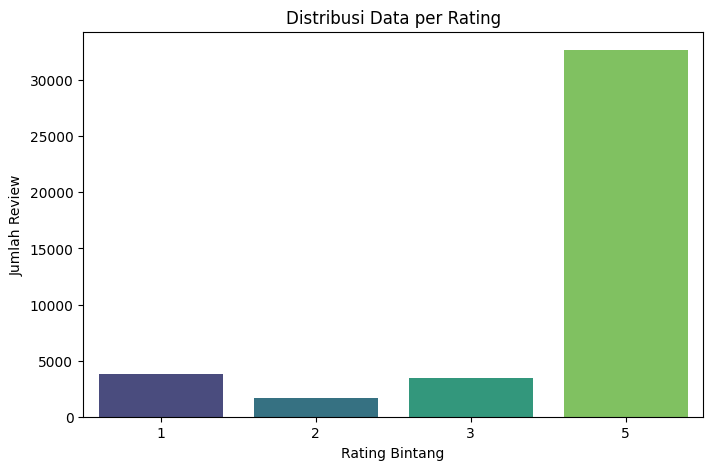

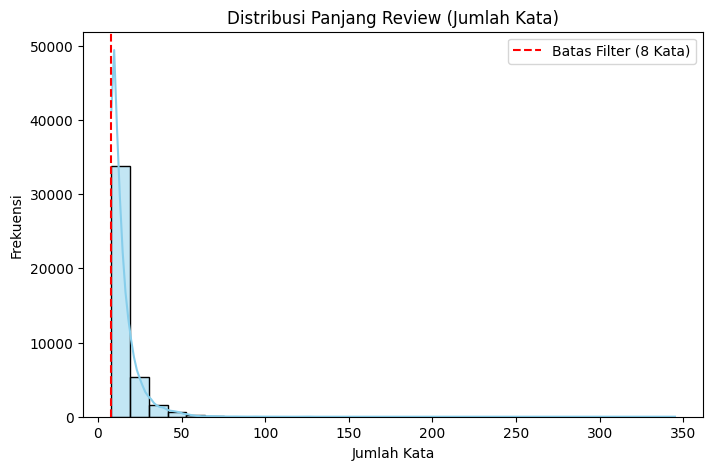


=== Data terpendek (Top 5) ===


,Rating,Review,word_count
28,5,Bagus banget bikin muka glowing seharian dan l...,8
29,5,barang nyampek kondisi packing bagus n belum d...,8
35,5,Ingredient: bagus Product benefit: mencerahkan...,8
36,5,Manfaat produk: bikin kulit jadi lembut dan be...,8
40,5,Aku cocok pake ini ..bersih banget wajahku seg...,8


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
# Ganti nama file sesuai dengan file hasil scraping kamu
file_path = "dataset_tokopedia_final.csv"
df = pd.read_csv(file_path)

# Pastikan tipe data benar
df['Rating'] = df['Rating'].astype(int)
df['Review'] = df['Review'].astype(str)

# 2. Hitung jumlah kata per review
df['word_count'] = df['Review'].apply(lambda x: len(x.split()))

print("=== Ringkasan Statistik ===")
print(df.describe())

# 3. Visualisasi Distribusi Rating (Class Distribution)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Distribusi Data per Rating')
plt.xlabel('Rating Bintang')
plt.ylabel('Jumlah Review')
plt.savefig('distribusi_rating.png')
plt.show()

# 4. Visualisasi Sebaran Panjang Review (Word Count)
plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue')
plt.axvline(8, color='red', linestyle='--', label='Batas Filter (8 Kata)')
plt.title('Distribusi Panjang Review (Jumlah Kata)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.legend()
plt.savefig('distribusi_panjang_review.png')
plt.show()

# 5. Cek data yang sangat pendek (untuk validasi filter)
print("\n=== Data terpendek (Top 5) ===")
display(df.nsmallest(5, 'word_count')[['Rating', 'Review', 'word_count']])